# CFPB Consumer Complaint Analysis

Interactive exploration of prepaid card complaints filed with the Consumer Financial Protection Bureau (CFPB).

This notebook imports the `complaint_pipeline` package and uses its analysis functions to visualize complaint patterns for InComm and Blackhawk — the two largest prepaid card processors in the U.S.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from complaint_pipeline.cfpb import client, analyzer
from complaint_pipeline.cfpb import narrative

plt.style.use("seaborn-v0_8-muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

## 1. Fetch Complaint Data

Pull live data from the CFPB API using `httpx`. The API returns up to 1,000 complaints per query.

In [2]:
incomm = client.fetch_complaints("InComm")
blackhawk = client.fetch_complaints("Blackhawk")
all_complaints = incomm + blackhawk

print(f"InComm:    {len(incomm):,} complaints")
print(f"Blackhawk: {len(blackhawk):,} complaints")
print(f"Total:     {len(all_complaints):,} complaints")

InComm:    403 complaints
Blackhawk: 218 complaints
Total:     621 complaints


## 2. Overview

In [3]:
for label, complaints in [("InComm", incomm), ("Blackhawk", blackhawk)]:
    dr = analyzer.date_range(complaints)
    yearly = analyzer.yearly_breakdown(complaints)
    relief = analyzer.monetary_relief_rate(complaints)
    dispute = analyzer.disputed_rate(complaints)
    print(f"--- {label} ---")
    print(f"  Date range: {dr[0]} to {dr[1]}" if dr else "  No dates")
    print(f"  Yearly: {yearly}")
    print(f"  Monetary relief rate: {relief['relief_pct']}%")
    print(f"  Timely response rate: {relief['timely_pct']}%")
    print(f"  Consumer dispute rate: {dispute['dispute_rate_pct']}%")
    print()

--- InComm ---
  Date range: 2015-12-08T12:00:00-05:00 to 2025-12-23T12:00:00-05:00
  Yearly: {'2015': 2, '2016': 8, '2017': 7, '2018': 3, '2019': 11, '2020': 14, '2021': 9, '2022': 45, '2023': 79, '2024': 141, '2025': 84}
  Monetary relief rate: 2.7%
  Timely response rate: 75.9%
  Consumer dispute rate: 0.5%

--- Blackhawk ---
  Date range: 2015-03-27T12:00:00-05:00 to 2025-12-22T12:00:00-05:00
  Yearly: {'2015': 17, '2016': 17, '2017': 18, '2018': 8, '2019': 14, '2020': 21, '2021': 20, '2022': 17, '2023': 22, '2024': 27, '2025': 37}
  Monetary relief rate: 31.2%
  Timely response rate: 92.2%
  Consumer dispute rate: 5.0%



## 3. Monthly Complaint Trends

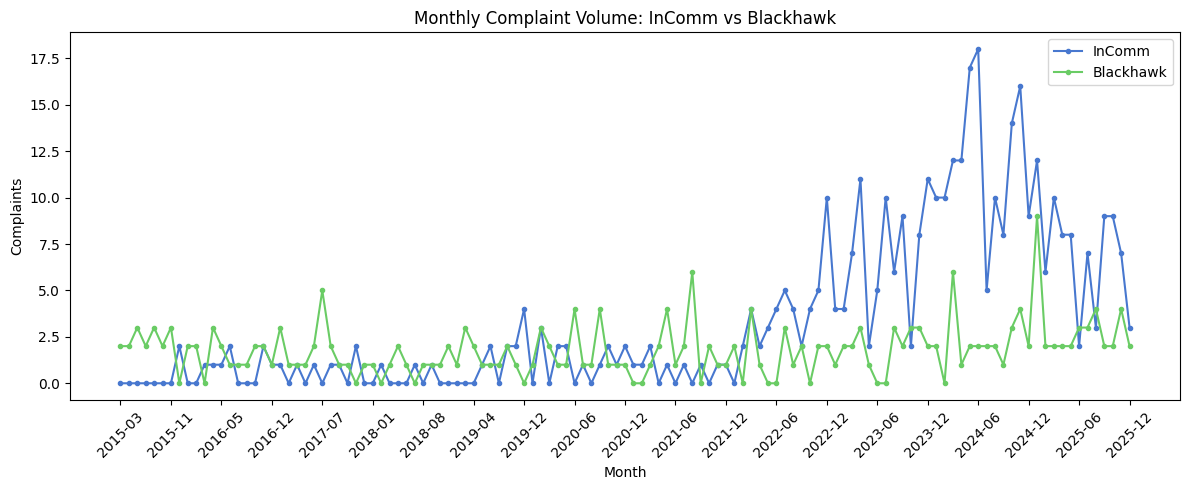

In [4]:
incomm_ts = analyzer.monthly_timeseries(incomm)
bhn_ts = analyzer.monthly_timeseries(blackhawk)

# Union of all months for aligned x-axis
all_months = sorted(set(incomm_ts) | set(bhn_ts))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(all_months, [incomm_ts.get(m, 0) for m in all_months], marker=".", label="InComm")
ax.plot(all_months, [bhn_ts.get(m, 0) for m in all_months], marker=".", label="Blackhawk")
ax.set_xlabel("Month")
ax.set_ylabel("Complaints")
ax.set_title("Monthly Complaint Volume: InComm vs Blackhawk")
ax.legend()

# Show every 6th month label to avoid crowding
ax.set_xticks(all_months[::6])
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 4. Geographic Distribution

Top 15 states by complaint volume.

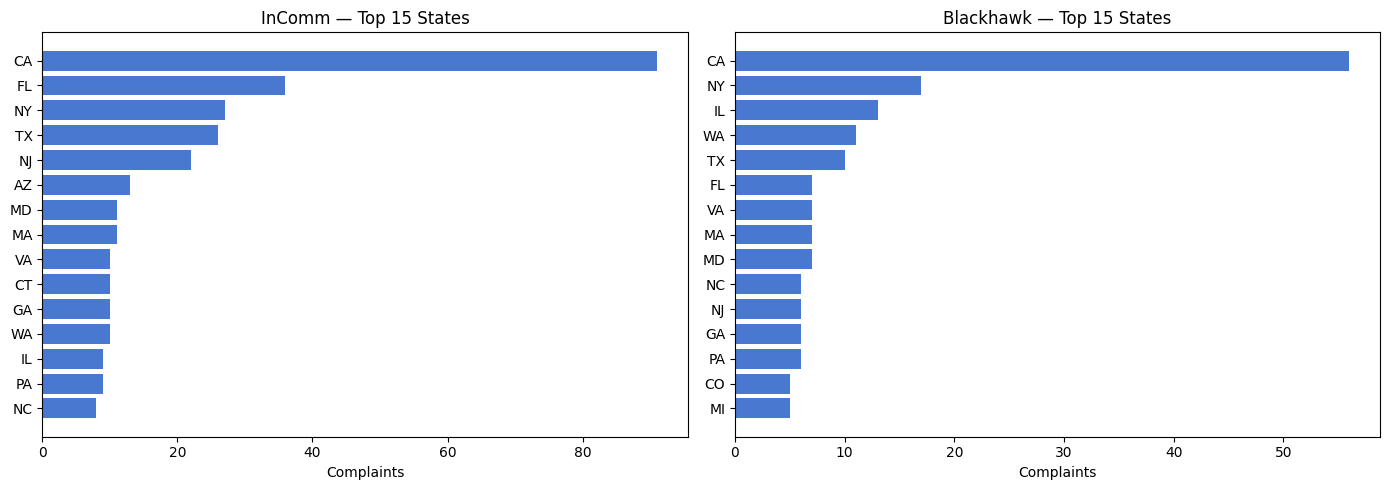

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, (label, complaints) in zip(axes, [("InComm", incomm), ("Blackhawk", blackhawk)]):
    geo = analyzer.geographic_analysis(complaints)[:15]
    states = [s for s, _ in geo]
    counts = [c for _, c in geo]
    ax.barh(states[::-1], counts[::-1])
    ax.set_xlabel("Complaints")
    ax.set_title(f"{label} — Top 15 States")

plt.tight_layout()
plt.show()

## 5. Text Mining: Denomination Targeting

Dollar amounts extracted from complaint narratives using regex. Common gift card denominations are highlighted.

Narratives with dollar amounts: 424 / 621


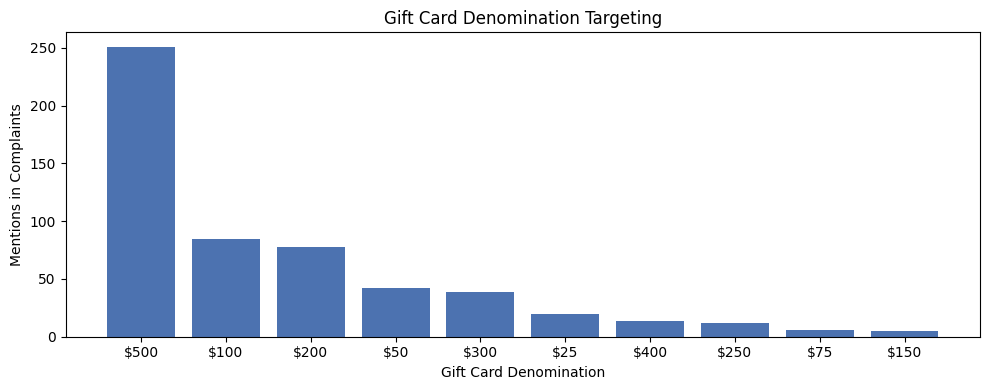

In [6]:
denom = narrative.denomination_targeting(all_complaints)

print(f"Narratives with dollar amounts: {denom['narratives_with_amounts']} / {denom['total_narratives']}")

# Plot denomination counts
if denom["denomination_counts"]:
    denoms = denom["denomination_counts"]
    labels = [f"${int(d)}" for d in denoms.keys()]
    values = list(denoms.values())

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(labels, values, color="#4c72b0")
    ax.set_xlabel("Gift Card Denomination")
    ax.set_ylabel("Mentions in Complaints")
    ax.set_title("Gift Card Denomination Targeting")
    plt.tight_layout()
    plt.show()
else:
    print("No denomination data found in narratives.")

## 6. Text Mining: Purchase-to-Drain Timing

How quickly are gift cards drained after purchase? Classified by keyword matching on complaint narratives.

Pre-activation drains detected: 4
Immediate drain rate: 27.9%


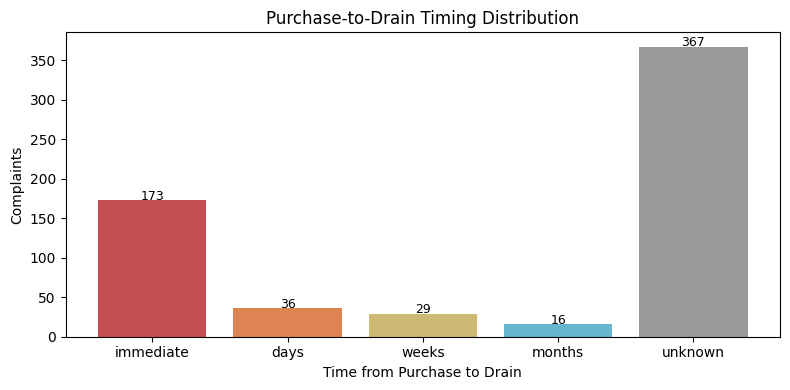

In [7]:
timing = narrative.purchase_to_drain_patterns(all_complaints)
dist = timing["timing_distribution"]

print(f"Pre-activation drains detected: {timing['pre_activation_drains']}")
print(f"Immediate drain rate: {timing['immediate_pct']}%")

# Filter out zero categories and 'unknown' for cleaner chart
categories = ["immediate", "days", "weeks", "months", "unknown"]
values = [dist[c] for c in categories]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#c44e52", "#dd8452", "#ccb974", "#64b5cd", "#999999"]
ax.bar(categories, values, color=colors)
ax.set_xlabel("Time from Purchase to Drain")
ax.set_ylabel("Complaints")
ax.set_title("Purchase-to-Drain Timing Distribution")

# Add count labels on bars
for i, v in enumerate(values):
    if v > 0:
        ax.text(i, v + 0.5, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 7. Text Mining: Fraud Classification

Keyword-scoring classifier: was the card drained before the buyer ever used it (pre-shelf) or after activation (post-activation)?

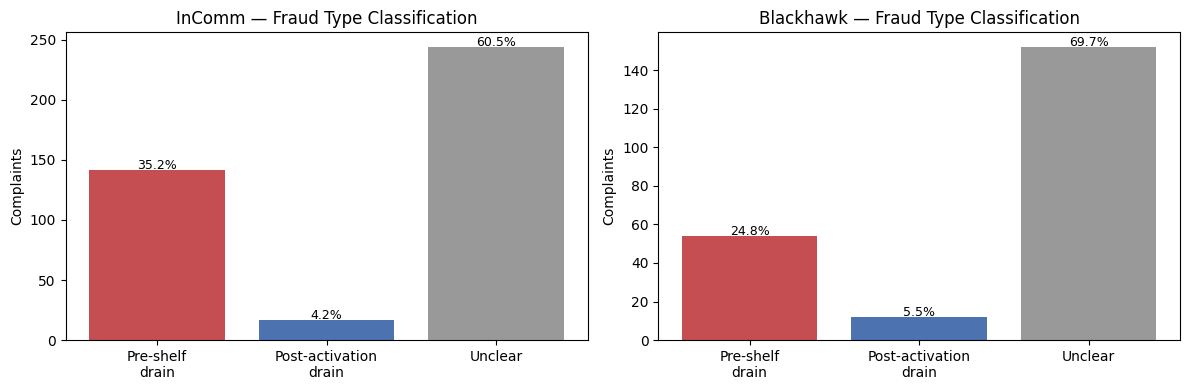

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (label, complaints) in zip(axes, [("InComm", incomm), ("Blackhawk", blackhawk)]):
    fraud = narrative.classify_fraud_type(complaints)
    categories = ["Pre-shelf\ndrain", "Post-activation\ndrain", "Unclear"]
    values = [fraud["pre_shelf_drain"], fraud["post_activation_drain"], fraud["unclear"]]
    colors = ["#c44e52", "#4c72b0", "#999999"]
    ax.bar(categories, values, color=colors)
    ax.set_ylabel("Complaints")
    ax.set_title(f"{label} — Fraud Type Classification")

    # Add percentage labels
    total = fraud["total_classified"]
    for i, v in enumerate(values):
        if v > 0 and total > 0:
            pct = round(100 * v / total, 1)
            ax.text(i, v + 0.5, f"{pct}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 8. Retailer Mentions

Where are consumers buying these gift cards? Extracted from complaint narratives.

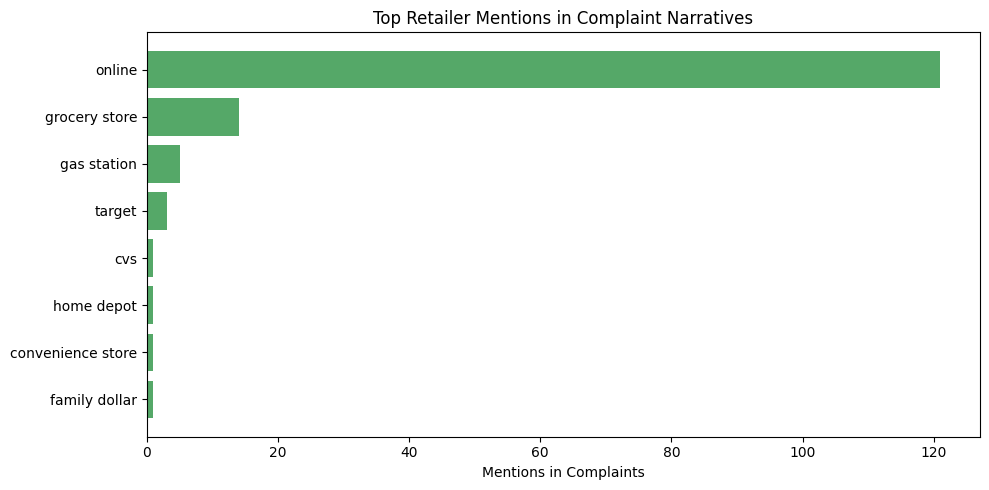

In [9]:
retailers = narrative.retailer_mentions(all_complaints)

# Show top 15 retailers
top_retailers = dict(list(retailers.items())[:15])

if top_retailers:
    names = list(top_retailers.keys())[::-1]
    counts = list(top_retailers.values())[::-1]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(names, counts, color="#55a868")
    ax.set_xlabel("Mentions in Complaints")
    ax.set_title("Top Retailer Mentions in Complaint Narratives")
    plt.tight_layout()
    plt.show()
else:
    print("No retailer mentions found in narratives.")

## 9. Company Response Patterns

How do companies respond? Analyzed from both the structured `company_response` field and keyword patterns in narratives.

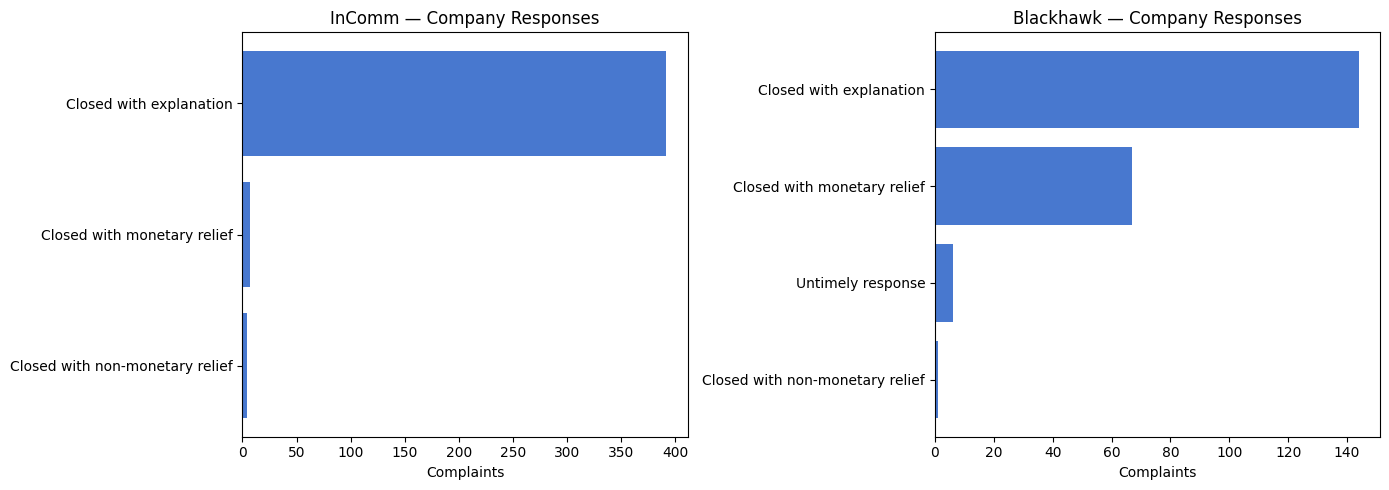

In [10]:
# Structured company_response field
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, complaints) in zip(axes, [("InComm", incomm), ("Blackhawk", blackhawk)]):
    responses = analyzer.response_analysis(complaints)
    if responses:
        names = [r for r, _ in responses[:8]][::-1]
        counts = [c for _, c in responses[:8]][::-1]
        ax.barh(names, counts)
    ax.set_xlabel("Complaints")
    ax.set_title(f"{label} — Company Responses")

plt.tight_layout()
plt.show()

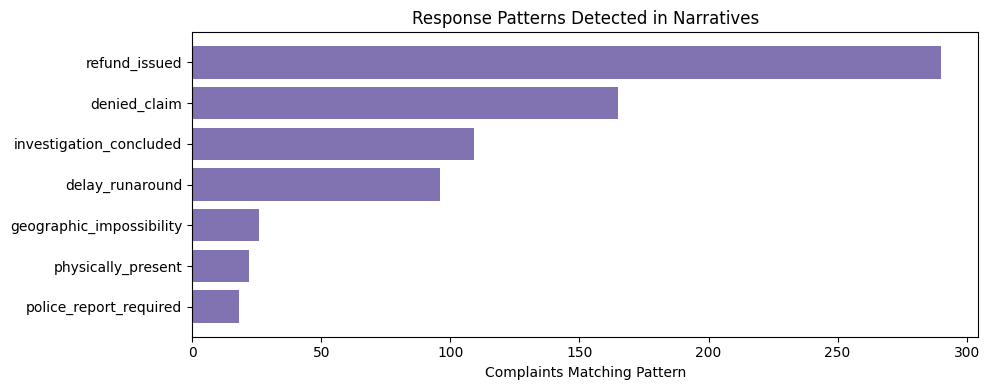

In [11]:
# Narrative-based response patterns (keyword scoring)
patterns = narrative.response_patterns(all_complaints)

if patterns["narrative_patterns"]:
    pat = patterns["narrative_patterns"]
    names = list(pat.keys())[::-1]
    counts = list(pat.values())[::-1]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(names, counts, color="#8172b2")
    ax.set_xlabel("Complaints Matching Pattern")
    ax.set_title("Response Patterns Detected in Narratives")
    plt.tight_layout()
    plt.show()

## 10. Narrative Keywords

Frequency of key terms across all complaint narratives.

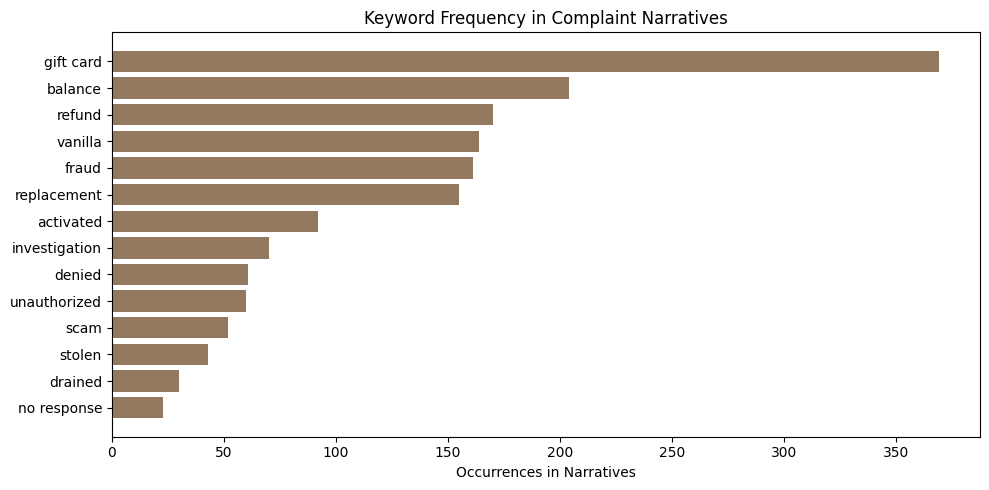

In [12]:
keywords = analyzer.narrative_keyword_counts(all_complaints)

if keywords:
    words = list(keywords.keys())[::-1]
    counts = list(keywords.values())[::-1]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(words, counts, color="#937860")
    ax.set_xlabel("Occurrences in Narratives")
    ax.set_title("Keyword Frequency in Complaint Narratives")
    plt.tight_layout()
    plt.show()

## 11. Top Issues

Most common complaint categories reported to the CFPB.

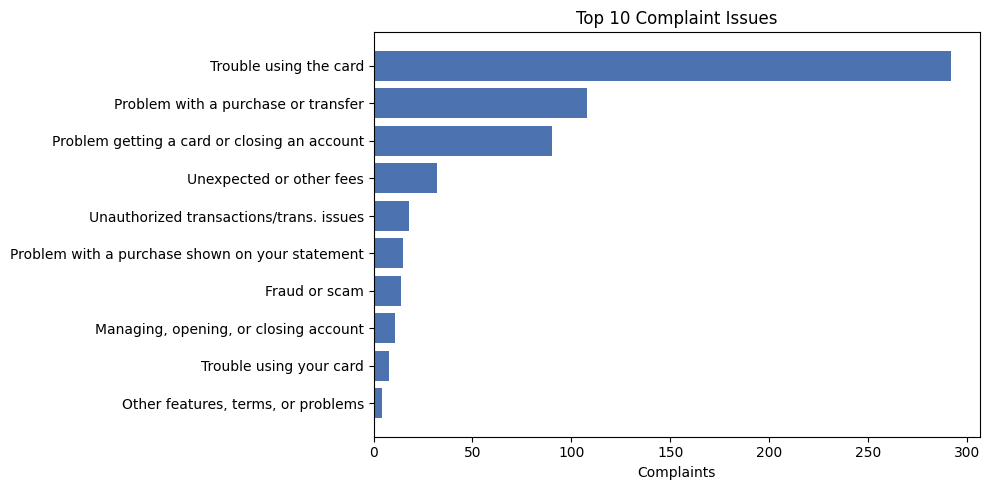

In [13]:
issues = analyzer.issue_analysis(all_complaints)

if issues:
    top = issues[:10]
    names = [i for i, _ in top][::-1]
    counts = [c for _, c in top][::-1]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(names, counts, color="#4c72b0")
    ax.set_xlabel("Complaints")
    ax.set_title("Top 10 Complaint Issues")
    plt.tight_layout()
    plt.show()

## Key Findings

This analysis demonstrates the pipeline's text mining capabilities on live CFPB data:

- **Dollar extraction** identifies which gift card denominations are most targeted
- **Timing classification** reveals how quickly cards are drained — many before the buyer ever uses them
- **Fraud type scoring** separates pre-shelf drains (supply chain tampering) from post-activation fraud
- **Retailer mentions** surface where consumers purchase affected cards
- **Response pattern analysis** exposes common company behaviors (investigation denials, delays, geographic impossibility claims)

All analysis functions are pure (data in, results out) and importable from the `complaint_pipeline` package. The same functions power the CLI tool's markdown reports.